# 03 — Réconciliation HAL × OpenAlex & qualité des données

**Objectif (data engineering).** Mesurer le recouvrement et la complémentarité
des deux sources ouvertes — brique de **fiabilisation** au cœur d'un entrepôt
décisionnel, dans le cadre du *record linkage* (Fellegi & Sunter, 1969 ;
Christen, 2012).

**Méthode rigoureuse.** Apparier deux échantillons tirés indépendamment serait
biaisé (les tranches se recouvrent peu par construction). On procède donc par
**recherche de DOI** : on prélève un échantillon d'une source et on cherche ses
DOI dans l'autre (lookup par lots). C'est symétrique et non biaisé. Un second
étage **probabiliste par titre** récupère les paires sans DOI commun.

Données 100 % réelles (fenêtre 2022-2024).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from lib import set_seeds, OpenAlexClient, HalClient, load_mart
from lib.textnorm import normalize_doi, token_set, jaccard
from lib.viz import new_axes, PALETTE

set_seeds()
FROM, TO, N = 2022, 2024, 1500

## 1. Échantillons de notices à DOI (les deux sources)

In [2]:
oa = OpenAlexClient()
oa_filter = oa.institution_filter(
    **{"from_publication_date": f"{FROM}-01-01", "to_publication_date": f"{TO}-12-31", "has_doi": "true"}
)
oa_works = [
    {"doi": normalize_doi(w.get("doi")), "title": w.get("title") or ""}
    for w in oa.iter_works(oa_filter, "doi,title", N)
]
oa_works = [w for w in oa_works if w["doi"]]

hal = HalClient()
hal_works = [
    {
        "doi": normalize_doi(d.get("doiId_s")),
        "title": (d.get("title_s") or [""])[0] if isinstance(d.get("title_s"), list) else (d.get("title_s") or ""),
    }
    for d in hal.iter_works(FROM, TO, N, require_doi=True)
]
hal_works = [w for w in hal_works if w["doi"]]
print(f"Échantillon OpenAlex : {len(oa_works):,} notices | HAL : {len(hal_works):,} notices")

Échantillon OpenAlex : 1,500 notices | HAL : 1,500 notices


## 2. Recouvrement bidirectionnel par recherche de DOI

- Quelle part de l'échantillon **HAL** est retrouvée dans OpenAlex ?
- Quelle part de l'échantillon **OpenAlex** est retrouvée dans HAL ?

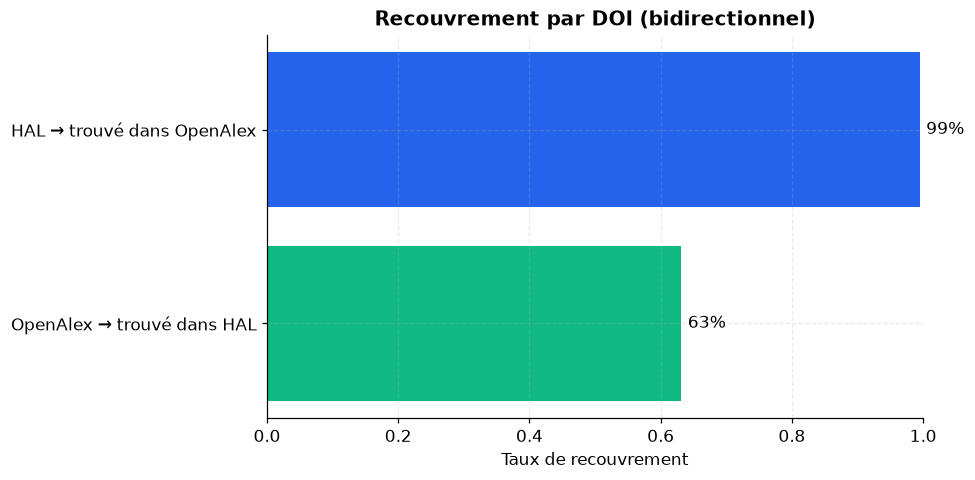

,direction,retrouvés,échantillon,taux
0,HAL → trouvé dans OpenAlex,1492,1500,99.5%
1,OpenAlex → trouvé dans HAL,947,1500,63.1%


In [3]:
hal_dois = [w["doi"] for w in hal_works]
oa_dois = [w["doi"] for w in oa_works]

hal_in_oa = oa.find_existing_dois(hal_dois)
oa_in_hal = hal.find_existing_dois(oa_dois)

cov_hal = len(hal_in_oa) / len(hal_dois)
cov_oa = len(oa_in_hal) / len(oa_dois)

coverage = pd.DataFrame(
    {
        "direction": ["HAL → trouvé dans OpenAlex", "OpenAlex → trouvé dans HAL"],
        "retrouvés": [len(hal_in_oa), len(oa_in_hal)],
        "échantillon": [len(hal_dois), len(oa_dois)],
        "taux": [f"{cov_hal:.1%}", f"{cov_oa:.1%}"],
    }
)
ax = new_axes("Recouvrement par DOI (bidirectionnel)", xlabel="Taux de recouvrement")
ax.barh(coverage["direction"], [cov_hal, cov_oa], color=PALETTE[:2])
ax.set_xlim(0, 1)
ax.invert_yaxis()
for i, v in enumerate([cov_hal, cov_oa]):
    ax.text(v + 0.01, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()
coverage

**Lecture.** OpenAlex couvre largement les DOI de HAL (couverture internationale
fondée sur Crossref), tandis qu'une part des DOI d'OpenAlex n'est pas déposée
dans HAL : c'est la **part propre à OpenAlex**. L'asymétrie quantifie
directement la complémentarité des deux sources.

## 3. Appariement probabiliste par titre (notices HAL sans DOI commun)

Pour les notices HAL **non** retrouvées par DOI, on tente un appariement par
similarité de titre contre l'échantillon OpenAlex (*blocking* par premier jeton,
seuil de Jaccard 0,6).

In [4]:
oa_blocks: dict[str, list[set[str]]] = {}
for w in oa_works:
    toks = token_set(w["title"])
    if toks:
        oa_blocks.setdefault(min(toks)[:1], []).append(toks)

hal_unmatched = [w for w in hal_works if w["doi"] not in hal_in_oa]
title_recovered = 0
for w in hal_unmatched:
    toks = token_set(w["title"])
    if not toks:
        continue
    if any(jaccard(toks, cand) >= 0.6 for cand in oa_blocks.get(min(toks)[:1], [])):
        title_recovered += 1
print(f"Notices HAL sans DOI commun        : {len(hal_unmatched):,}")
print(f"Récupérées par similarité de titre : {title_recovered:,}")

Notices HAL sans DOI commun        : 5
Récupérées par similarité de titre : 0


## 4. Cohérence avec le mart `reconciliation` du dashboard

In [5]:
recon = load_mart("reconciliation")
method = recon["matchMethod"]
print(f"Mart (6000/source) — DOI : {method['doi']} | titre : {method['fuzzyTitle']}")
print(f"Notebook — recouvrement HAL→OpenAlex : {cov_hal:.1%} | OpenAlex→HAL : {cov_oa:.1%}")
print("→ L'appariement repose d'abord sur le DOI ; le titre n'apporte qu'un complément marginal.")

Mart (6000/source) — DOI : 2017 | titre : 76
Notebook — recouvrement HAL→OpenAlex : 99.5% | OpenAlex→HAL : 63.1%
→ L'appariement repose d'abord sur le DOI ; le titre n'apporte qu'un complément marginal.


**Synthèse.** Le DOI est la clé d'appariement dominante ; l'étage titre n'ajoute
qu'un appoint marginal (confirmé par le mart : 76 paires titre contre 2 017 DOI).
Le recouvrement bidirectionnel établit la **complémentarité** : consolider HAL
et OpenAlex dans l'entrepôt apporte strictement plus qu'une source unique.

Note : le notebook mesure un **taux de recouvrement directionnel** sur un
échantillon (1 500/source, 2022-2024), tandis que le mart rapporte un **nombre
de paires appariées dédupliquées** (6 000/source) — deux vues complémentaires
de la même réconciliation, à ne pas confondre.